# Track-and-Hold (TH)

$$
H_\mathrm{TH}(f) \approx \frac{1}{2}
\left(
    1 + \mathrm{sinc}\left( \frac{f}{2f_s} \right)e^{-j\pi f T_s/2}
\right)
$$

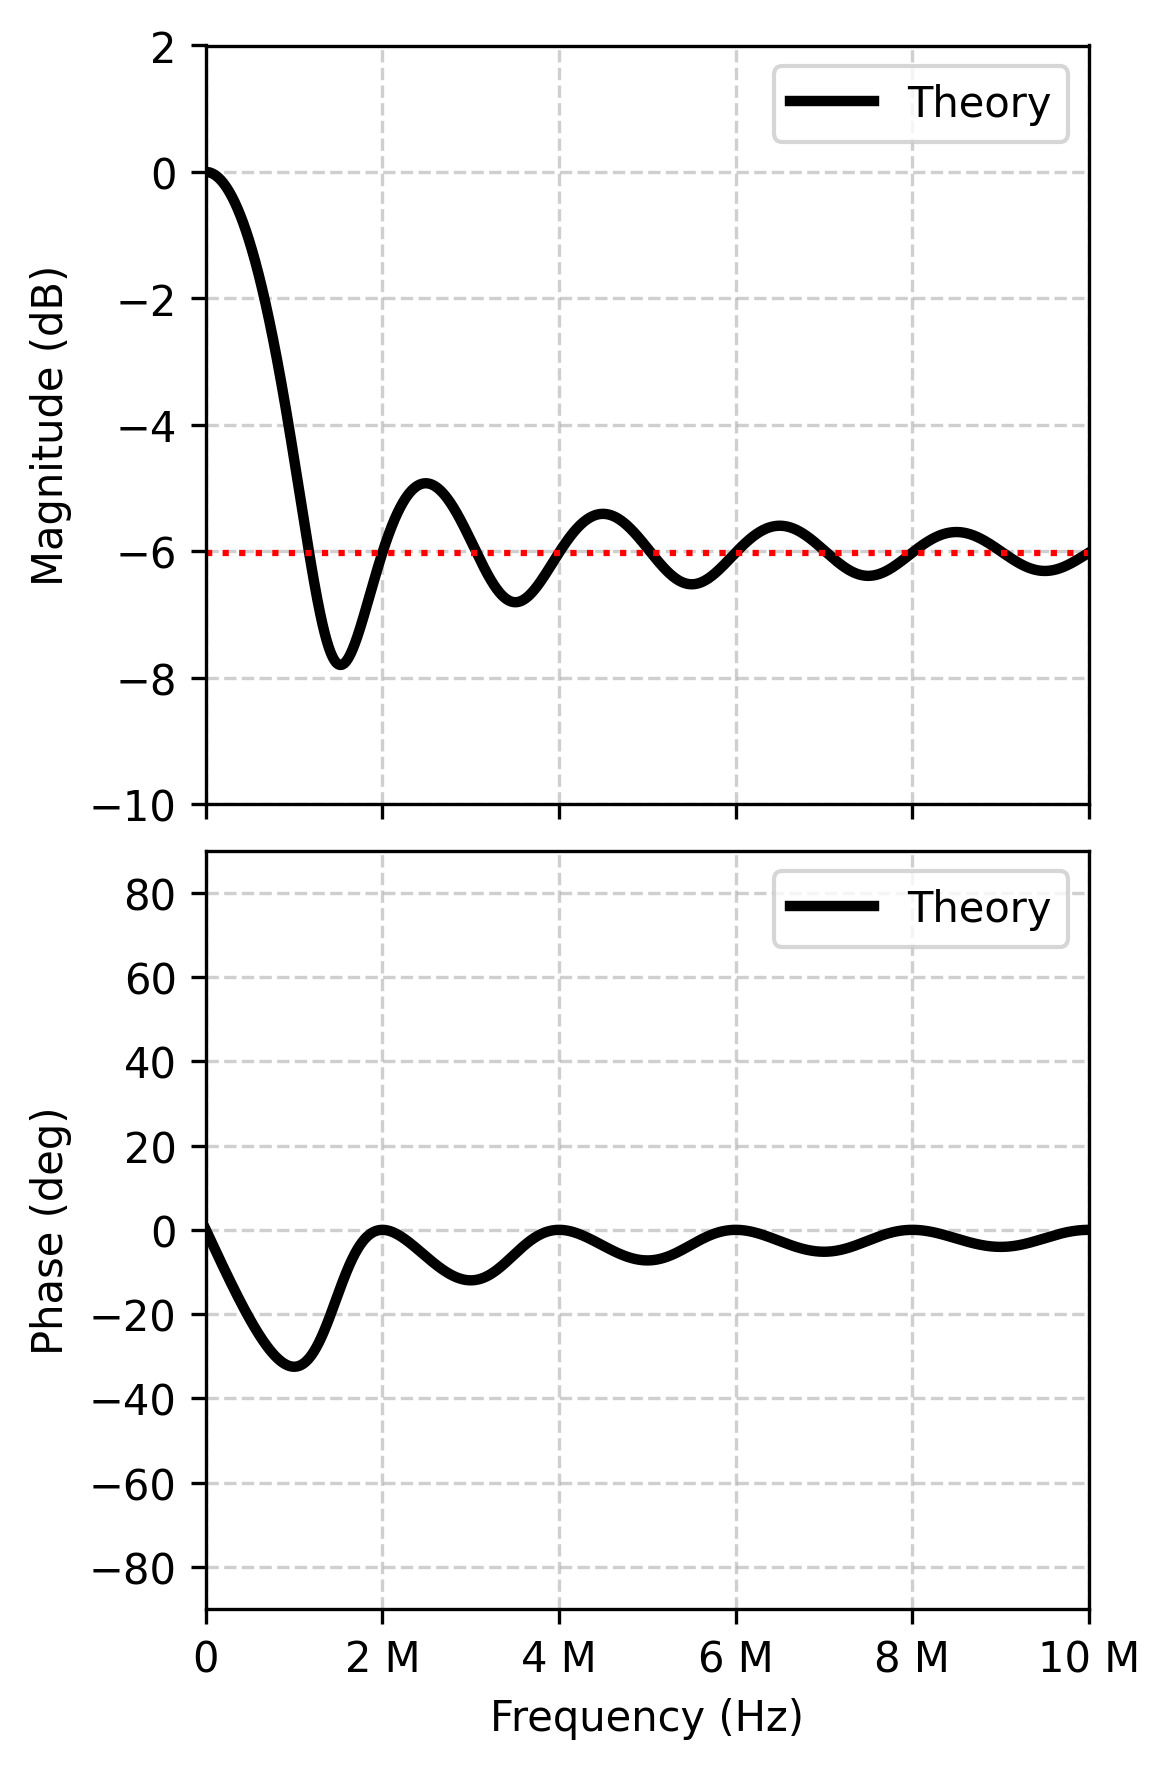

In [ ]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from matplotlib.ticker import EngFormatter

"""Import simulated data (tsv)"""
# df = pd.read_csv("cad5_data.tsv", sep="\t", header=None)

fs, fmax = 1e6, 10e6
f = np.linspace(0, fmax, 10000)
H = 0.5 + 0.5 * np.sinc(f/(2*fs)) * np.exp(-1j*np.pi*f/(2*fs))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 6), sharex=True, dpi=300)

# AC Magnitude response
ax1.plot(f, 20*np.log10(np.abs(H)), lw=2.5, c='black', label='Theory')
ax1.axhline(20*np.log10(0.5), c='red', ls=':')
ax1.set(ylim=(-10, 2), ylabel='Magnitude (dB)')

# AC Phase response
ax2.plot(f, np.angle(H, deg=True), lw=2.5, c='black', label='Theory')
ax2.set(xlim=(0, fmax), ylim=(-90, 90), xlabel='Frequency (Hz)', ylabel='Phase (deg)')
ax2.xaxis.set_major_formatter(EngFormatter(places=0))

"""Plot simulated data (tsv)"""
# ax1.plot(df[0], df[1], "--y", lw=1, label='Simulated')    # Magnitude
# ax2.plot(df[0], df[2], "--y", lw=1, label='Simulated')    # Phase

for ax in (ax1, ax2):
    ax.grid(True, ls='--', alpha=0.6)
    ax.legend()

plt.tight_layout(h_pad=0.5)
plt.show()